# Customer Segmentation Project
### Using RFM Analysis + K-Means Clustering

Dataset: UCI Online Retail II  
Source: https://archive.ics.uci.edu/dataset/502/online+retail+ii

The idea is to group customers based on their purchase behaviour — specifically how recently they bought, how often, and how much they spent. Then use clustering to find natural groups and figure out who the 'best' customers are vs who's probably gone.

I've seen this called RFM analysis — Recency, Frequency, Monetary.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## Loading the data

There are two sheets in the excel file (2009-2010 and 2010-2011). I'll use the second one, it's bigger.

In [49]:
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011', engine='openpyxl')
print(df.shape)
df.head()

(541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [51]:
# how many nulls
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

ok so ~135k rows with no Customer ID. that's a lot — like 25% of the data. not sure if I should try to fill them or just drop. I think dropping is fine because we can't do customer-level analysis without knowing who the customer is anyway.

In [52]:
df['Description'].value_counts().head(20)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
POSTAGE                               1253
JUMBO BAG PINK POLKADOT               1251
HEART OF WICKER SMALL                 1237
JAM MAKING SET WITH JARS              1229
JUMBO STORAGE BAG SUKI                1214
PAPER CHAIN KIT 50'S CHRISTMAS        1210
JUMBO SHOPPER VINTAGE RED PAISLEY     1202
LUNCH BAG CARS BLUE                   1197
LUNCH BAG SPACEBOY DESIGN             1192
JAM MAKING SET PRINTED                1182
Name: count, dtype: int64

In [53]:
# let me look at what countries we have
df['Country'].value_counts()

Country
United Kingdom          495478
Germany                   9495
France                    8558
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European Community          61
RSA                         58


Almost everything is UK. I'll filter to UK only to keep it consistent — mixing currencies/behaviour across countries would mess things up.

In [54]:
# look at the quantity column — something seems off
df['Quantity'].describe()

count    541910.000000
mean          9.552234
std         218.080957
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [55]:
# negative quantities??
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
937,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [56]:
# all the negative ones have invoice starting with C — must be cancellations
df[df['Invoice'].astype(str).str.startswith('C')]['Quantity'].describe()

count     9288.000000
mean       -29.885228
std       1145.786965
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

In [57]:
df['Price'].describe()

count    541910.000000
mean          4.611138
std          96.759765
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: Price, dtype: float64

In [58]:
# some prices are 0 or negative too
df[df['Price'] <= 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1510,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1985,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1986,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
2022,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom


## Cleaning

Things to fix:
- drop rows with no Customer ID
- remove cancelled orders (C invoices)
- remove rows where price or quantity is 0 or negative
- filter to UK only

In [59]:
df_clean = df.copy()

df_clean = df_clean.dropna(subset=['Customer ID'])
print('after dropping null customers:', df_clean.shape)

df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print('after removing cancellations:', df_clean.shape)

df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
print('after removing bad qty/price:', df_clean.shape)

df_clean = df_clean[df_clean['Country'] == 'United Kingdom']
print('after filtering to UK:', df_clean.shape)

after dropping null customers: (406830, 8)
after removing cancellations: (397925, 8)
after removing bad qty/price: (397885, 8)
after filtering to UK: (354321, 8)


In [60]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [61]:
print('date range:', df_clean['InvoiceDate'].min(), 'to', df_clean['InvoiceDate'].max())
print('unique customers:', df_clean['Customer ID'].nunique())
print('total revenue: £', round(df_clean['TotalPrice'].sum(), 2))

date range: 2010-12-01 08:26:00 to 2011-12-09 12:49:00
unique customers: 3920
total revenue: £ 7308391.55


## Quick EDA before RFM

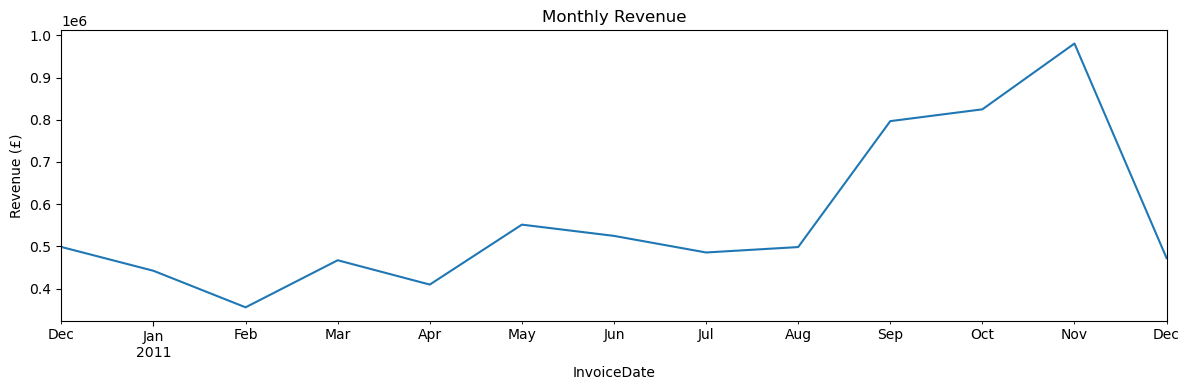

In [62]:
# revenue over time — just curious
df_clean.set_index('InvoiceDate')['TotalPrice'].resample('M').sum().plot(figsize=(12,4), title='Monthly Revenue')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

In [63]:
# top customers by total spend
df_clean.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Customer ID
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
16684.0     66653.56
14096.0     65164.79
13694.0     65039.62
15311.0     60767.90
Name: TotalPrice, dtype: float64

customer 14646 spent nearly £280k?? seems like a business customer or something. probably won't affect the clustering much since we're standardizing but worth noting.

## Building RFM features

In [64]:
# reference date = day after last purchase in dataset
snapshot = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print('snapshot date:', snapshot)

snapshot date: 2011-12-10 12:49:00


In [65]:
rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12747.0,2,11,4196.01
2,12748.0,1,209,33719.73
3,12749.0,4,5,4090.88
4,12820.0,3,4,942.34
5,12821.0,214,1,92.72
6,12822.0,71,2,948.88
7,12823.0,75,5,1759.50
8,12824.0,60,1,397.12
9,12826.0,3,7,1474.72


In [66]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,3920.000000,3920.000000,3920.000000,3920.000000
mean,15562.059694,92.208418,4.246429,1864.385601
std,1576.594671,99.533854,7.199202,7482.817477
min,12346.000000,1.000000,1.000000,3.750000
25%,14208.750000,18.000000,1.000000,300.280000
50%,15569.500000,51.000000,2.000000,652.280000
75%,16913.250000,143.000000,5.000000,1576.585000
max,18287.000000,374.000000,209.000000,259657.300000


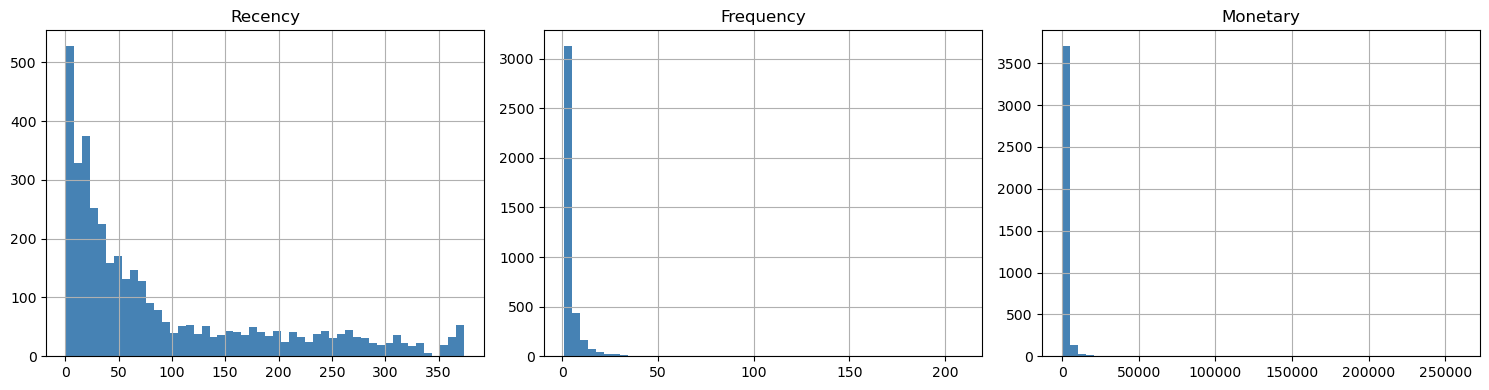

In [67]:
# some people only ordered once and spent like £3. also someone ordered 209 times
# let's look at distributions

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

rfm['Recency'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Recency')

rfm['Frequency'].hist(bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Frequency')

rfm['Monetary'].hist(bins=50, ax=axes[2], color='steelblue')
axes[2].set_title('Monetary')

plt.tight_layout()
plt.show()

all three are really skewed right. this will be a problem for kmeans since it uses euclidean distance — outliers will pull the centroids all over the place.

I'll try log transforming first.

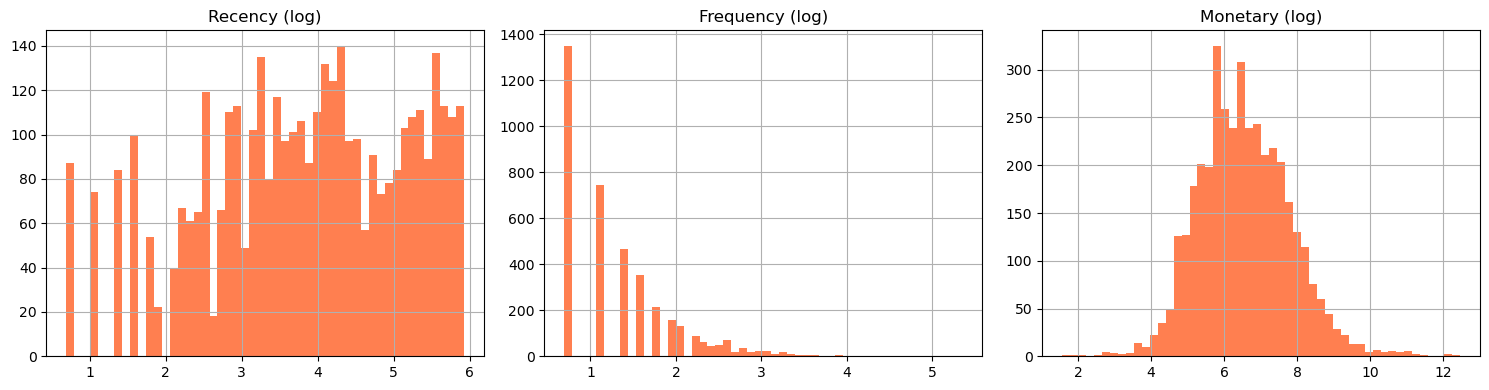

In [68]:
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rfm_log['Recency'].hist(bins=50, ax=axes[0], color='coral')
axes[0].set_title('Recency (log)')
rfm_log['Frequency'].hist(bins=50, ax=axes[1], color='coral')
axes[1].set_title('Frequency (log)')
rfm_log['Monetary'].hist(bins=50, ax=axes[2], color='coral')
axes[2].set_title('Monetary (log)')
plt.tight_layout()
plt.show()

much better. now scaling.

In [69]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])
rfm_scaled.describe().round(2)

,Recency,Frequency,Monetary
count,3920.00,3920.00,3920.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-2.34,-0.96,-4.01
25%,-0.66,-0.96,-0.67
50%,0.09,-0.36,-0.05
75%,0.85,0.65,0.66
max,1.57,5.86,4.76


## How many clusters?

I'll try the elbow method first — run kmeans for k=2 to 10 and see where the inertia stops dropping fast.

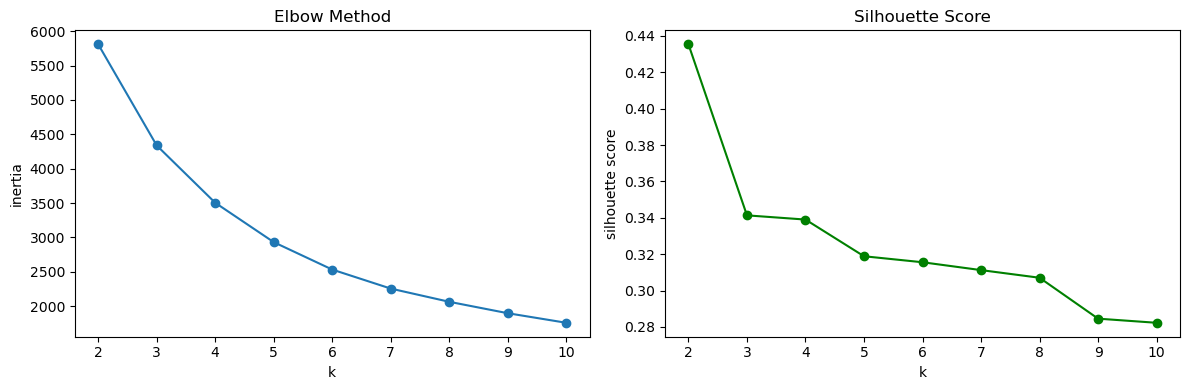

k=2: silhouette=0.4354
k=3: silhouette=0.3414
k=4: silhouette=0.3390
k=5: silhouette=0.3189
k=6: silhouette=0.3156
k=7: silhouette=0.3113
k=8: silhouette=0.3071
k=9: silhouette=0.2846
k=10: silhouette=0.2823


In [70]:
inertias = []
sil_scores = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(K, inertias, 'o-')
ax1.set_xlabel('k')
ax1.set_ylabel('inertia')
ax1.set_title('Elbow Method')

ax2.plot(K, sil_scores, 'o-', color='green')
ax2.set_xlabel('k')
ax2.set_ylabel('silhouette score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(K, sil_scores):
    print(f'k={k}: silhouette={s:.4f}')

elbow looks like it bends around k=3 or k=4. silhouette is highest at k=2 but that feels too coarse — you'd just get 'good customers' and 'bad customers' which isn't that useful. k=4 has a decent score and makes more business sense, so I'll go with 4.

## K-Means with k=4

In [71]:
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km4.fit_predict(rfm_scaled)

rfm['Cluster'].value_counts()

Cluster
0    1461
2    1051
3     776
1     632
Name: count, dtype: int64

In [72]:
# look at the actual values per cluster
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

,Recency,Frequency,Monetary
Cluster,,,
0,182.8,1.3,331.8
1,11.6,13.7,7251.4
2,68.5,4.2,1744.0
3,19.4,2.1,525.6


ok let me look at this and figure out which cluster is which:

- look at which cluster has low recency (bought recently), high frequency, high monetary → those are the best customers (Champions)
- high recency + low frequency + low monetary → lost/inactive
- somewhere in between → loyal or at-risk

I need to match the cluster numbers to actual labels by looking at the means above.

In [73]:
# sort by monetary to rank them
cluster_means = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_means['rank_by_monetary'] = cluster_means['Monetary'].rank(ascending=False)
cluster_means.sort_values('Monetary', ascending=False)

,Recency,Frequency,Monetary,rank_by_monetary
Cluster,,,,
1,11.6,13.7,7251.4,1.0
2,68.5,4.2,1744.0,2.0
3,19.4,2.1,525.6,3.0
0,182.8,1.3,331.8,4.0


In [74]:
# assign labels based on the output above — adjust if your cluster numbers differ
# (cluster numbers can change between runs, check the means table)

sorted_clusters = rfm.groupby('Cluster')['Monetary'].mean().sort_values(ascending=False).index.tolist()

label_map = {
    sorted_clusters[0]: 'Champions',
    sorted_clusters[1]: 'Loyal',
    sorted_clusters[2]: 'At-Risk',
    sorted_clusters[3]: 'Lost'
}

rfm['Segment'] = rfm['Cluster'].map(label_map)
print(rfm['Segment'].value_counts())

Segment
Lost         1461
Loyal        1051
At-Risk       776
Champions     632
Name: count, dtype: int64


In [75]:
# sanity check — do the segments make sense?
rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

,Recency,Frequency,Monetary
Segment,,,
At-Risk,19.4,2.1,525.6
Champions,11.6,13.7,7251.4
Lost,182.8,1.3,331.8
Loyal,68.5,4.2,1744.0


that looks right. champions have the lowest recency (bought most recently), highest frequency and highest spend. lost customers are the opposite.

## Visualisations

In [76]:
colors = {
    'Champions': '#2ecc71',
    'Loyal':     '#3498db',
    'At-Risk':   '#e67e22',
    'Lost':      '#e74c3c'
}

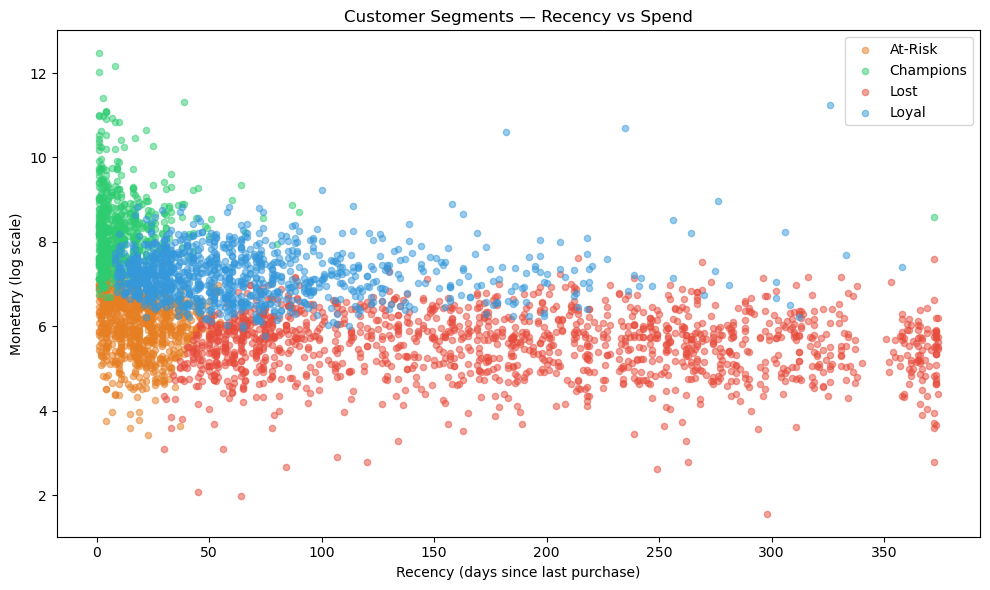

In [77]:
# scatter: recency vs monetary
# monetary is still skewed so I'll plot log(monetary) to make it readable

fig, ax = plt.subplots(figsize=(10, 6))

for seg, group in rfm.groupby('Segment'):
    ax.scatter(
        group['Recency'],
        np.log1p(group['Monetary']),
        label=seg, alpha=0.5, s=20,
        color=colors[seg]
    )

ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Monetary (log scale)')
ax.set_title('Customer Segments — Recency vs Spend')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_segments.png', dpi=120)
plt.show()

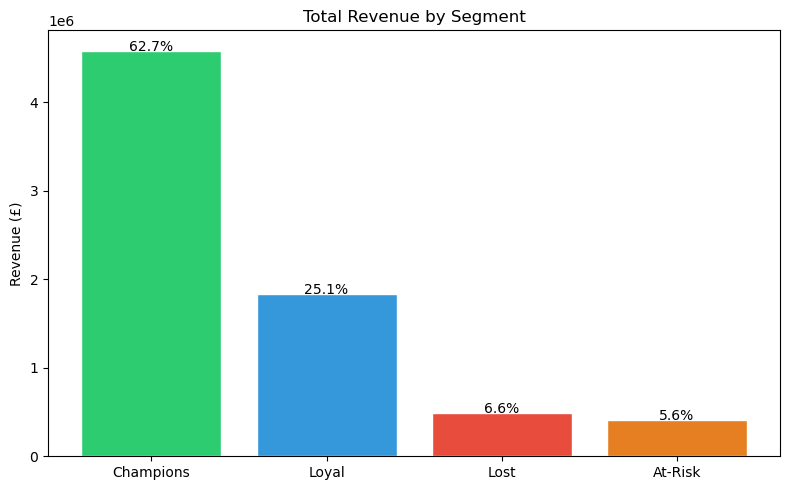

In [78]:
# revenue breakdown by segment
rev_by_seg = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(rev_by_seg.index, rev_by_seg.values,
              color=[colors[s] for s in rev_by_seg.index], edgecolor='white')

for bar in bars:
    pct = bar.get_height() / rev_by_seg.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{pct:.1f}%', ha='center', fontsize=10)

ax.set_title('Total Revenue by Segment')
ax.set_ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=120)
plt.show()

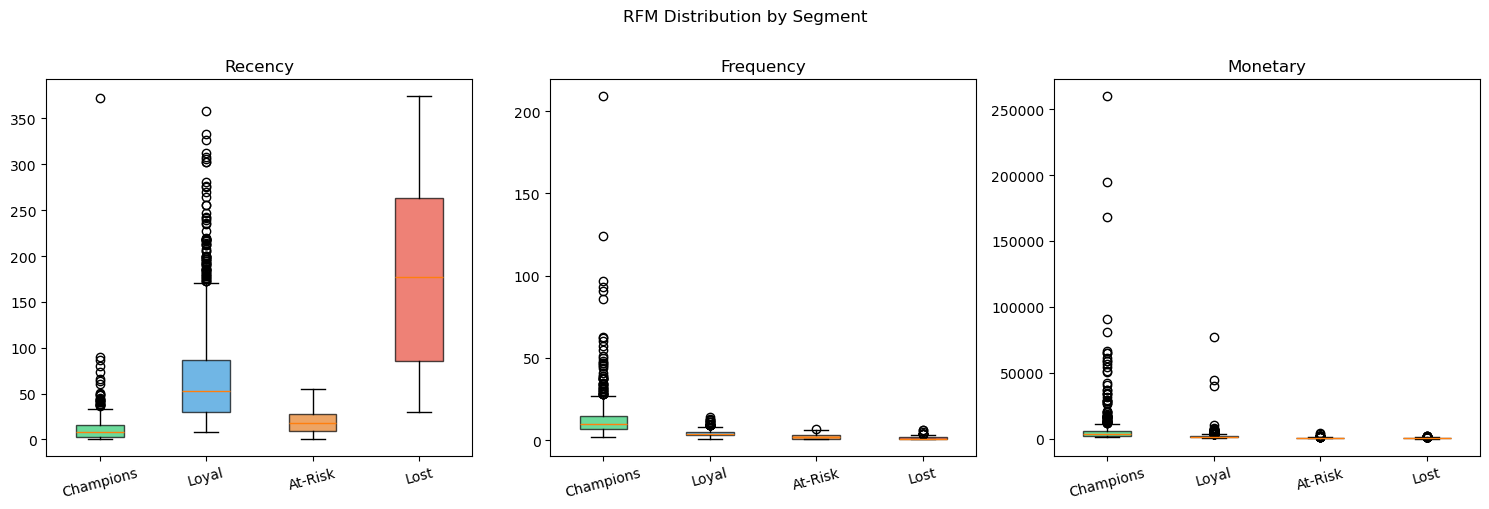

In [85]:
# boxplots — want to see the spread within each segment

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

segment_order = ['Champions', 'Loyal', 'At-Risk', 'Lost']

for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    data_to_plot = [rfm[rfm['Segment'] == s][col].values for s in segment_order]
    bp = ax.boxplot(data_to_plot, labels=segment_order, patch_artist=True)
    for patch, seg in zip(bp['boxes'], segment_order):
        patch.set_facecolor(colors[seg])
        patch.set_alpha(0.7)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('RFM Distribution by Segment', y=1.01)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=120)
plt.show()

the monetary boxplot has some extreme outliers in Champions — those big business customers. probably fine for the segmentation since they're correctly identified as Champions anyway.

## Summary & Takeaways

In [84]:
summary = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean'),
    Total_Revenue = ('Monetary',    'sum')
).round(1)

summary['Revenue_%'] = (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(1)
summary.sort_values('Avg_Monetary', ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_%
Segment,,,,,,
Champions,632,11.6,13.7,7251.4,4582893.5,62.7
Loyal,1051,68.5,4.2,1744.0,1832893.0,25.1
At-Risk,776,19.4,2.1,525.6,407896.0,5.6
Lost,1461,182.8,1.3,331.8,484709.0,6.6


### What does this tell us?

**Champions** — buy often, spent the most, bought recently. These are your most valuable customers. Worth investing in retention — loyalty perks, early access, maybe a personal email. They're also most likely to respond to upsells.

**Loyal** — decent frequency and spend, just not quite at Champions level. Could be nudged up with targeted offers. Think about bundle deals or "you might also like" recommendations.

**At-Risk** — used to buy regularly but haven't come back in a while. This group is worth a re-engagement campaign. A discount code or "we miss you" email could win some of them back before they're fully gone.

**Lost** — low everything. Probably one-time buyers who never came back. Not worth spending a lot on — maybe a single low-cost campaign but don't burn budget here.

One thing I noticed: Champions are a small % of customers but will likely account for most of the revenue. That's the 80/20 rule in action pretty much.

In [81]:
# export the segmented customer list in case it's useful
rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Segment']].to_csv('customer_segments.csv', index=False)
print('saved to customer_segments.csv')

saved to customer_segments.csv


In [83]:
# --- Generated Charts ---
# (Outputs embedded directly into the notebook for preview)
print('Charts successfully rendered below:')

Charts successfully rendered below:
